https://archive.ics.uci.edu/dataset/211/communities+and+crime+unnormalized

In [1]:
#%pip install ucimlrepo
#%pip install seaborn

In [16]:
from ucimlrepo import fetch_ucirepo 
from pandas.plotting import scatter_matrix

import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
communities_and_crime_unnormalized = fetch_ucirepo(id=211) 
  
X = communities_and_crime_unnormalized.data.features 
y = communities_and_crime_unnormalized.data.targets 

In [4]:
df = pd.concat([X, y], axis=1)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


In [5]:
X.info(verbose=True,show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2215 entries, 0 to 2214
Data columns (total 125 columns):
 #    Column               Non-Null Count  Dtype  
---   ------               --------------  -----  
 0    State                2215 non-null   object 
 1    pop                  2215 non-null   int64  
 2    perHoush             2215 non-null   float64
 3    pctBlack             2215 non-null   float64
 4    pctWhite             2215 non-null   float64
 5    pctAsian             2215 non-null   float64
 6    pctHisp              2215 non-null   float64
 7    pct12-21             2215 non-null   float64
 8    pct12-29             2215 non-null   float64
 9    pct16-24             2215 non-null   float64
 10   pct65up              2215 non-null   float64
 11   persUrban            2215 non-null   int64  
 12   pctUrban             2215 non-null   float64
 13   medIncome            2215 non-null   int64  
 14   pctWwage             2215 non-null   float64
 15   pctWfarm           

In [6]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2215 entries, 0 to 2214
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   murders          2215 non-null   int64  
 1   murdPerPop       2215 non-null   float64
 2   rapes            2007 non-null   float64
 3   rapesPerPop      2007 non-null   float64
 4   robberies        2214 non-null   float64
 5   robbbPerPop      2214 non-null   float64
 6   assaults         2202 non-null   float64
 7   assaultPerPop    2202 non-null   float64
 8   burglaries       2212 non-null   float64
 9   burglPerPop      2212 non-null   float64
 10  larcenies        2212 non-null   float64
 11  larcPerPop       2212 non-null   float64
 12  autoTheft        2212 non-null   float64
 13  autoTheftPerPop  2212 non-null   float64
 14  arsons           2124 non-null   float64
 15  arsonsPerPop     2124 non-null   float64
 16  violentPerPop    1994 non-null   float64
 17  nonViolPerPop 

In [7]:
print(X.isnull().sum())

State                     0
pop                       0
perHoush                  0
pctBlack                  0
pctWhite                  0
pctAsian                  0
pctHisp                   0
pct12-21                  0
pct12-29                  0
pct16-24                  0
pct65up                   0
persUrban                 0
pctUrban                  0
medIncome                 0
pctWwage                  0
pctWfarm                  0
pctWdiv                   0
pctWsocsec                0
pctPubAsst                0
pctRetire                 0
medFamIncome              0
perCapInc                 0
whitePerCap               0
blackPerCap               0
NAperCap                  0
asianPerCap               0
otherPerCap               1
hispPerCap                0
persPoverty               0
pctPoverty                0
pctLowEdu                 0
pctNotHSgrad              0
pctCollGrad               0
pctUnemploy               0
pctEmploy                 0
pctEmployMfg        

In [8]:
print(y.isnull().sum())

murders              0
murdPerPop           0
rapes              208
rapesPerPop        208
robberies            1
robbbPerPop          1
assaults            13
assaultPerPop       13
burglaries           3
burglPerPop          3
larcenies            3
larcPerPop           3
autoTheft            3
autoTheftPerPop      3
arsons              91
arsonsPerPop        91
violentPerPop      221
nonViolPerPop       97
dtype: int64


In [9]:
print(df.isnull().sum().sum())

42147


In [10]:
df.describe()

,pop,perHoush,pctBlack,pctWhite,pctAsian,pctHisp,pct12-21,pct12-29,pct16-24,pct65up,persUrban,pctUrban,medIncome,pctWwage,pctWfarm,pctWdiv,pctWsocsec,pctPubAsst,pctRetire,medFamIncome,perCapInc,whitePerCap,blackPerCap,NAperCap,asianPerCap,otherPerCap,hispPerCap,persPoverty,pctPoverty,pctLowEdu,pctNotHSgrad,pctCollGrad,pctUnemploy,pctEmploy,pctEmployMfg,pctEmployProfServ,pctOccupManu,pctOccupMgmt,pctMaleDivorc,pctMaleNevMar,pctFemDivorc,pctAllDivorc,persPerFam,pct2Par,pctKids2Par,pctKids-4w2Par,pct12-17w2Par,pctWorkMom-6,pctWorkMom-18,kidsBornNevrMarr,pctKidsBornNevrMarr,numForeignBorn,pctFgnImmig-3,pctFgnImmig-5,pctFgnImmig-8,pctFgnImmig-10,pctImmig-3,pctImmig-5,pctImmig-8,pctImmig-10,pctSpeakOnlyEng,pctNotSpeakEng,pctLargHousFam,pctLargHous,persPerOccupHous,persPerOwnOccup,persPerRenterOccup,pctPersOwnOccup,pctPopDenseHous,pctSmallHousUnits,medNumBedrm,houseVacant,pctHousOccup,pctHousOwnerOccup,pctVacantBoarded,pctVacant6up,medYrHousBuilt,pctHousWOphone,pctHousWOplumb,ownHousLowQ,ownHousMed,ownHousUperQ,ownHousQrange,rentLowQ,rentMed,rentUpperQ,rentQrange,medGrossRent,medRentpctHousInc,medOwnCostpct,medOwnCostPctWO,persEmergShelt,persHomeless,pctForeignBorn,pctBornStateResid,pctSameHouse-5,pctSameCounty-5,pctSameState-5,numPolice,policePerPop,policeField,policeFieldPerPop,policeCalls,policCallPerPop,policCallPerOffic,policePerPop2,racialMatch,pctPolicWhite,pctPolicBlack,pctPolicHisp,pctPolicAsian,pctPolicMinority,officDrugUnits,numDiffDrugsSeiz,policAveOT,landArea,popDensity,pctUsePubTrans,policCarsAvail,policOperBudget,pctPolicPatrol,gangUnit,pctOfficDrugUnit,policBudgetPerPop,murders,murdPerPop,rapes,rapesPerPop,robberies,robbbPerPop,assaults,assaultPerPop,burglaries,burglPerPop,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,violentPerPop,nonViolPerPop
count,2.215000e+03,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2.215000e+03,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2214.000000,2215.000000,2.215000e+03,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2.215000e+03,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,343.000000,343.000000,343.000000,343.000000,3.430000e+02,3.430000e+02,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,2215.000000,2215.000000,2215.000000,343.000000,3.430000e+02,343.000000,343.000000,2215.000000,3.430000e+02,2215.000000,2215.000000,2007.000000,2007.00000,2214.000000,2214.000000,2202.000000,2202.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2124.000000,2124.000000,1994.000000,2118.000000
mean,5.311798e+04,2.707327,9.335102,83.979819,2.670203,7.950176,14.445837,27.644840,13.975142,11.836393,4.773472e+04,70.465309,33984.696163,78.312758,0.881842,43.750935,26.409418,6.801445,15.969002,39857.055079,15603.524605,16567.698420,11541.749436,12229.191422,14227.989616,9442.765131,11018.998194,7.590853e+03,11.620537,9.186646,22.305120,23.056876,6.045242,62.021612,18.228907,24.532298,13.819165,28.209201,9.127585,30.683517,12.325300,10.812515,3.129698,74.059129,71.227255,81.865422,75.52

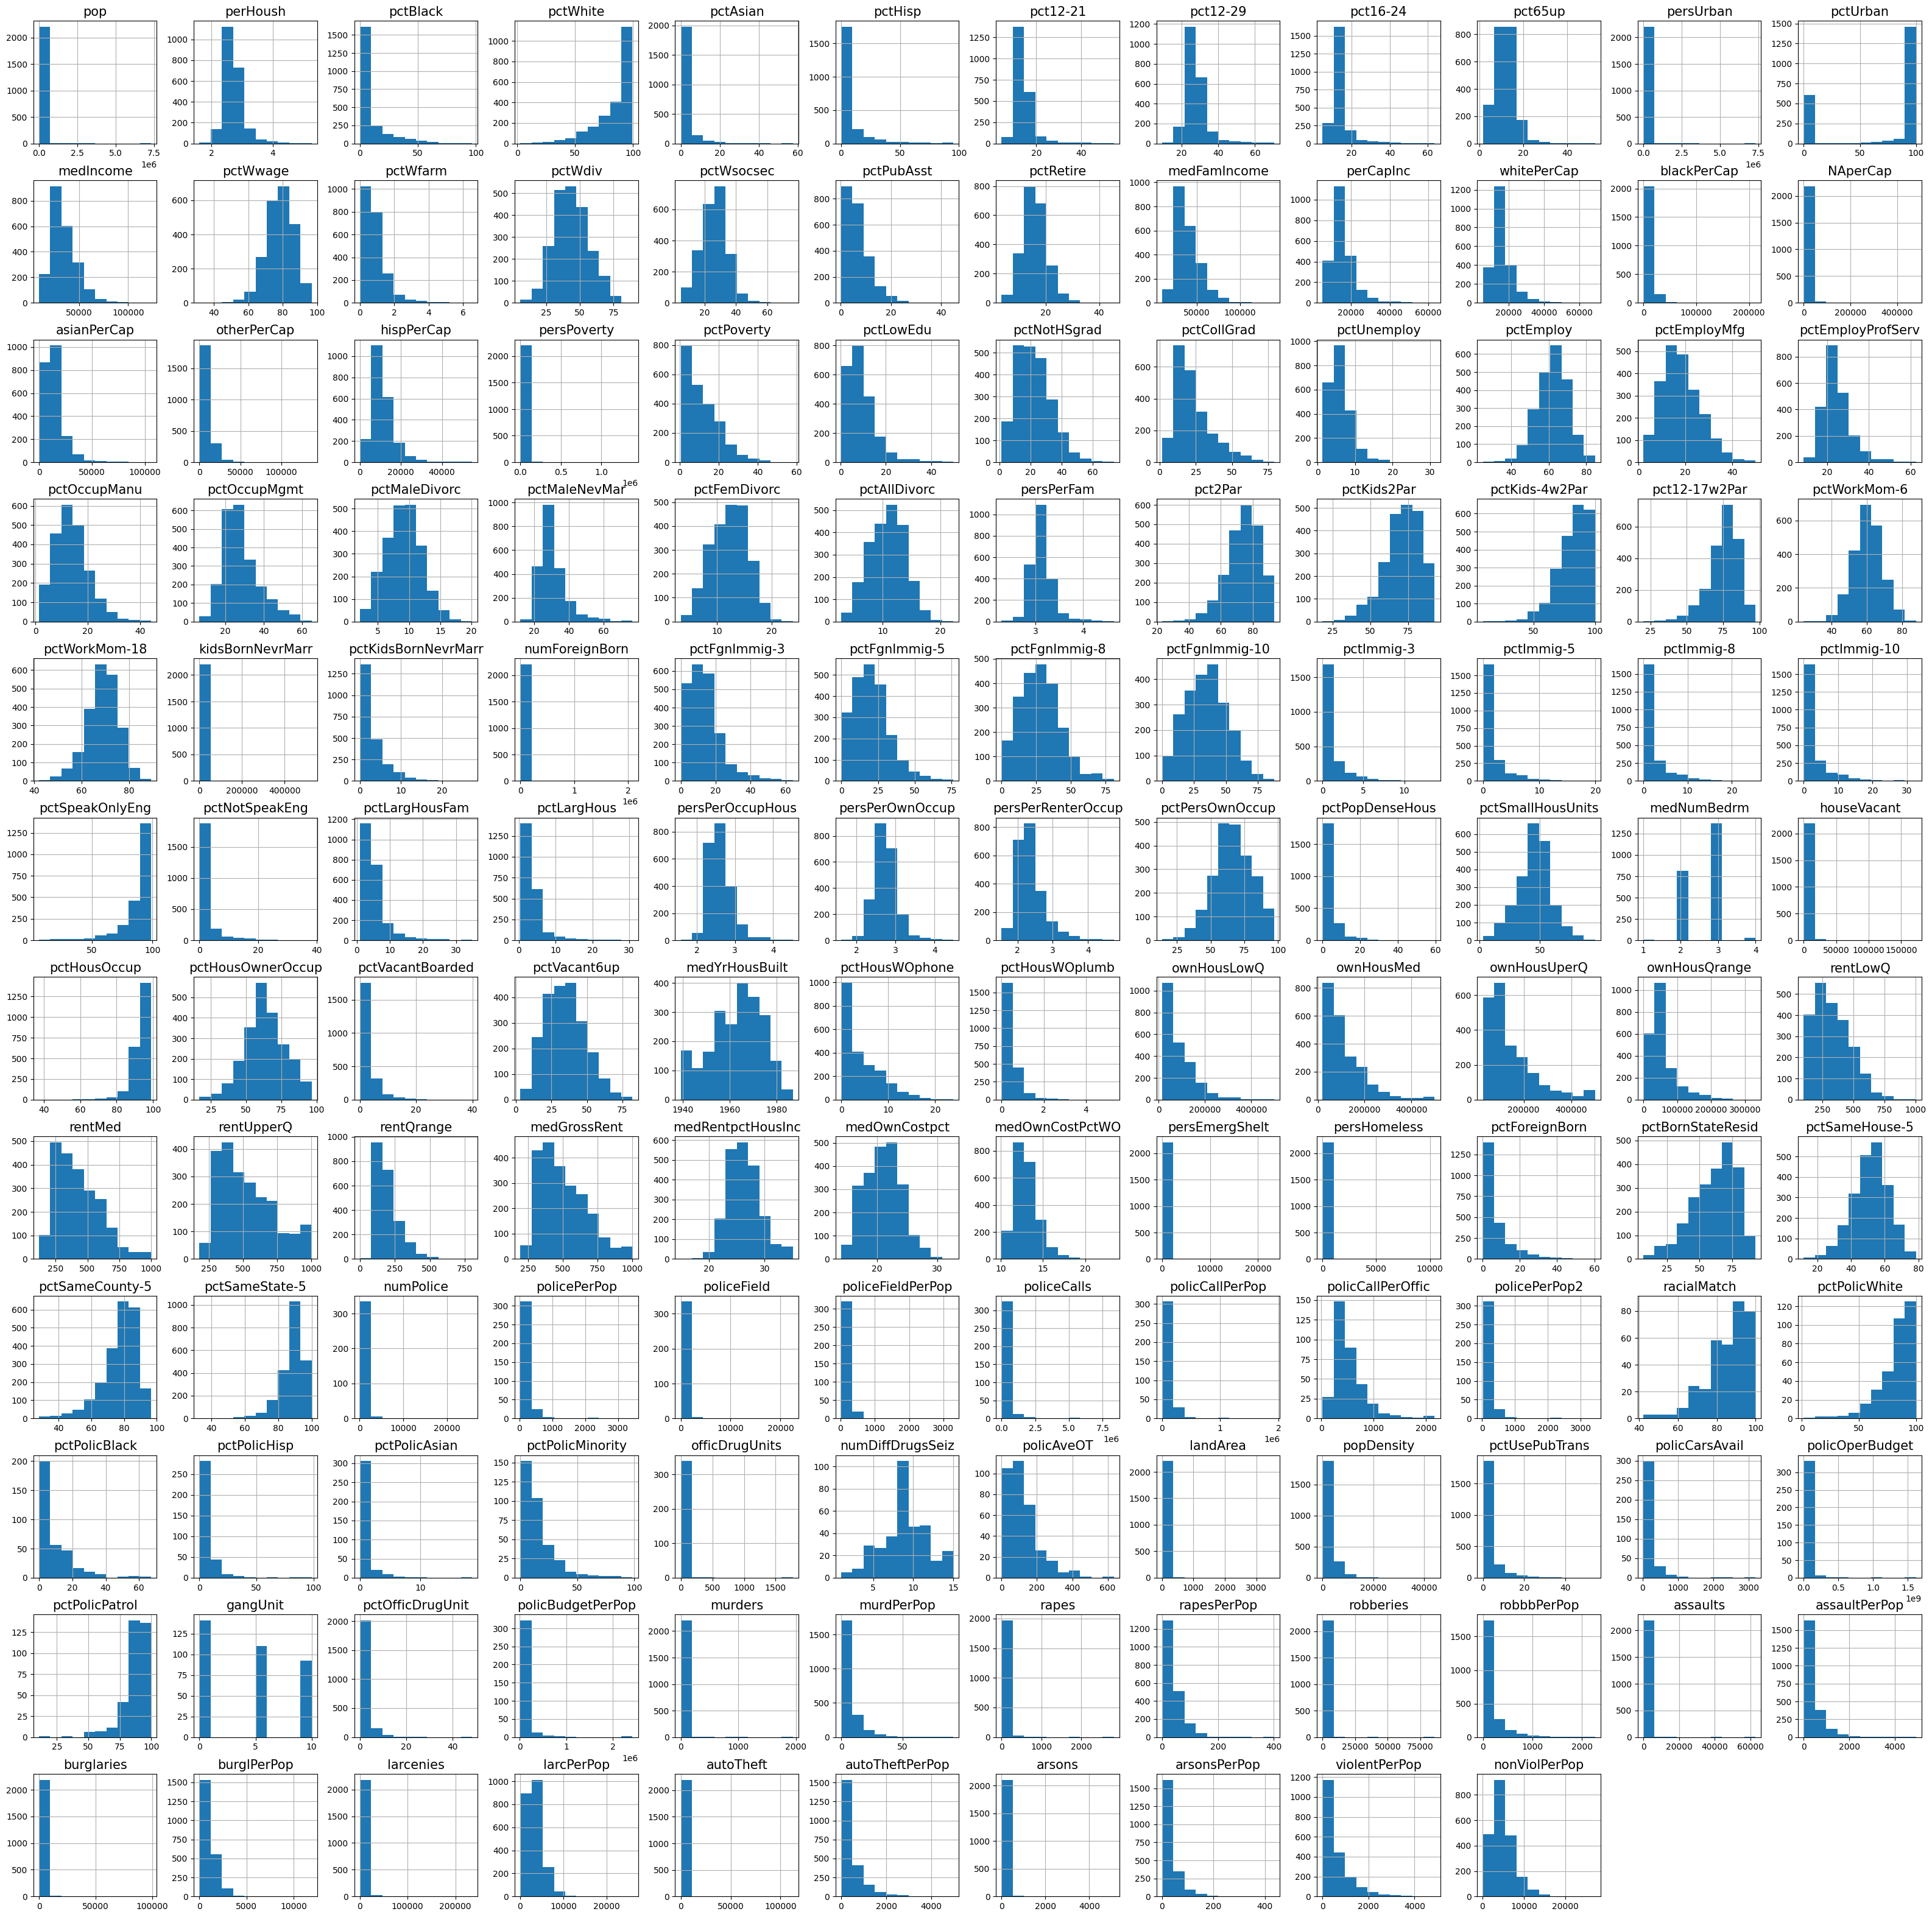

In [11]:
plt.rc('font', size=10)
plt.rc('axes', labelsize=10, titlesize=15)
plt.rc('legend', fontsize=10)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

df.hist(figsize=(40,40))
#save_fig("Tabela de distrubuição dos dados")
plt.show()

In [12]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix['rapes'].sort_values(ascending=False)

rapes                  1.000000
burglaries             0.954737
larcenies              0.946720
houseVacant            0.925453
pop                    0.919863
persUrban              0.919677
persPoverty            0.917066
autoTheft              0.915183
assaults               0.902012
arsons                 0.900531
murders                0.897017
policCarsAvail         0.890901
kidsBornNevrMarr       0.880269
policeCalls            0.868807
numPolice              0.858100
robberies              0.857094
policeField            0.853955
policOperBudget        0.852571
persEmergShelt         0.793777
numForeignBorn         0.783679
officDrugUnits         0.782815
persHomeless           0.735825
robbbPerPop            0.419784
murdPerPop             0.345844
autoTheftPerPop        0.336675
violentPerPop          0.336088
pctUsePubTrans         0.301750
pctKidsBornNevrMarr    0.293782
rapesPerPop            0.282439
pctVacantBoarded       0.268001
landArea               0.264706
arsonsPe

In [ ]:
axes = scatter_matrix(df, figsize=(40, 40), diagonal='hist')

plt.subplots_adjust(hspace=0.2, wspace=0.2)

#save_fig("Pairplot")
plt.show()